# Neural Networks for Data Science Applications
## End-of-term homework: Advanced transfer learning

**Name**: Cem Şirin

**Matricola**: 2050640

> ✍ Upload the completed notebook **at least two days** before your expected exam's date on the Google Classroom page. For example, for the **January 12th** session, you should upload it by **January 9th, 23:59 Rome time**.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

2024-02-09 22:35:56.664907: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# To ensure reproducible results (as much as possible)
tf.keras.utils.set_random_seed(1234)

### Instructions

1. The homework is divided into two exercises. The first one (**10 points**) is mandatory for everyone. The second one (**5 points**) is mandatory only if you have not submitted the first homework or if you want to increase the mark.
2. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2024).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use any external material or inspiration for the code, reference it *explicitly* in the corresponding cell. For the textual descriptions, copy-paste *is not allowed*. <ins>Not following these two points is an immediate 0 mark</ins>.

> 🔵 *Grammar*: for the textual descriptions, I will remove points for too many grammatical or textual errors. Please try to be precise and provide nice-to-read descriptions, like if you were writing a report.

> 🟥 *Vectorization and TensorFlow*: the homework must be done _fully in TensorFlow_ and vectorizing the code as much as possible (e.g., do not loop explicitly over the batch dimension).

> 🟪 *Math*: you can also use LaTeX in Markdown if you need to write equations or if you need generic math notation.

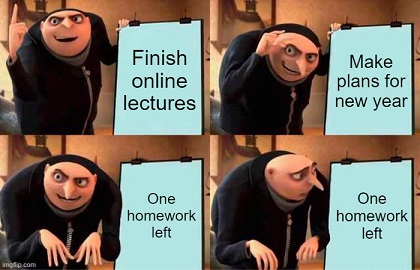

## Warmup: Data loading

**For this part, select an interesting dataset.**

*   This is similar to [Exercise 1 from the mid-term homework](https://colab.research.google.com/drive/1oDbshJeY62Id1O5pbsCrNFX9PdSY1ITP?usp=sharing), which you can check for completeness.
*   You should use a **different dataset** from the first homework, possibly of higher complexity.
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

✍ **DESCRIPTION OF THE CODE**

I am using the [Streetview Image Dataset](https://www.kaggle.com/datasets/ayuseless/streetview-image-dataset?rvi=1) which has approximately 25,000 geo-tagged images from Google Street View. Each image has a size of 640x640 pixels and is tagged with the latitude and longitude of the location it was taken from. Here is a sample from the dataset on 3.45°S, 54.56°W, i.e., State of Pará, Brazil:

<img src="images/1.jpg" height="300" alt="Sample image from the dataset">

The task is to predict the latitude and longitude of the location where the image was taken from. The model has to learn geographical features from the images and encode them in the latent space. The dataset is well distrubuted across the globe as you can on the heatmap below. You can find the code for generating the heatmap in the `data_loading.ipynb` notebook.

<img src="images/map.png" height="300">

In [ ]:
import pandas as pd
from vit_keras.vit import preprocess_inputs

AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 16
IMAGE_SIZE = 384
# For Kaggle
# dataset_dir = '/kaggle/input/streetview-image-dataset/Streetview_Image_Dataset'
dataset_dir = "gsv25k"


def load_image(path, loc):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE), method="bilinear")
    img = preprocess_inputs(img)
    return img, loc


def augment(img, loc):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, loc


def create_ds(df):
    file_paths = [f"{dataset_dir}/images/{i}.png" for i in df.index]
    locations = df[["latitude", "longitude"]].values
    ds = tf.data.Dataset.from_tensor_slices((file_paths, locations))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    # ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


df = pd.read_csv(dataset_dir + "/coordinates.csv")
# Divide df into train and test
train_df = df.sample(frac=0.8, random_state=1234)
val_df = df.drop(train_df.index)
test_df = val_df.sample(frac=0.5, random_state=1234)
val_df = val_df.drop(test_df.index)

train_ds = create_ds(train_df).map(augment)
val_ds = create_ds(val_df)
test_ds = create_ds(test_df)

### Exercise 1: Advanced transfer learning (10 points)

For this exercise, you are asked to implement some form of "advanced" transfer learning method. These include, but are not limited to, the content of Lecture 10 in the course, e.g.:

1.   **Parameter-efficient fine-tuning** (PEFT) methods (LoRA, adapters, soft prompting, ...).
2.   **Task vectors** and arithmetic in the weight space.
3.   **Model merging** and model combination (e.g., relative representations).

The following are useful surveys and papers you can take inspiration from. If you are in doubt, ask me before starting.

1. [Scaling Down to Scale Up: A Guide to Parameter-Efficient Fine-Tuning](https://arxiv.org/abs/2303.15647) - A survey on PEFT models.
2. [Modular Deep Learning](https://arxiv.org/abs/2302.11529) - A tutorial on the emerging paradigm of modular deep learning, in which networks are composed of modular building blocks. This is connected to PEFT, see in particular Section 7.
3. Examples of model merging: [model ratatouille](https://arxiv.org/abs/2212.10445), [git re-basin](https://arxiv.org/abs/2209.04836), [Fisher averaging](https://arxiv.org/abs/2111.09832).
4. Examples of task arithmetic: [simple arithmetic](https://arxiv.org/abs/2212.04089), [tangent space](https://arxiv.org/abs/2305.12827).

For this exercise, you can either transfer from two models that you trained autonomously (e.g., train one model on another dataset, add an adapter, fine-tune on the dataset you selected before), or fine-tune directly from a pre-trained model found on the web. For finding pre-trained models, you can check [tf.keras.applications](https://www.tensorflow.org/api_docs/python/tf/keras/applications), [TensorFlow model garden](https://www.tensorflow.org/guide/model_garden?hl=it), or the [Hugging Face Hub](https://huggingface.co/docs/hub/index).

> 🟥 Remember that the homework must be done fully in TensorFlow, with no external libraries (when in doubt, ask).

✍ **DESCRIPTION OF THE CODE**

### Introduction
A geolocation prediction consists of latitude and longitude, which are continuous values. Since regression tasks are more difficult to solve, many different methods have been proposed to improve the performance of the models, such as partitioning the world into grids and predicting the grid, or using a classification model to predict the latitude and longitude.

Recently, [Vincente et al.](https://arxiv.org/pdf/2309.16020v2.pdf) came up with a new method called **GeoClip**, which is a CLIP-inspired model where the geolocations are encoded in the latent space by a **location encoder**. Then, an **image encoder** is used to encode and align the image embeddings with the location embeddings.

I will be using a different dataset, and also extending their methodology by using **IA3** to fine tune the image encoder.

### Implementation details
I have implemented the same location encoder on Tenserflow, and coppied the weights. You can see the details of the implementation in the file `location_encoder.py`. Then, I took a pretrained ViT model from the library [vit-keras](https://github.com/faustomorales/vit-keras), and **added the capability to fine tune by using the IA3 method**. My implementation of IA3 is in the file `image_encoder.py`. The training is done in the following steps:

1. Train an alignment head on the image encoder, to align the image embeddings with the location embeddings. MSE loss is used to train the alignment head.
2. Unfreeze IA3 vectors ($l_k$, $l_q$, $l_ff$) and the location encoder, and train the model end-to-end. Symmetric Cross Entropy loss is used to train the model.

The code below is executed in Kaggle. To skip to the results, you can go to Results section.

In [ ]:
from tensorflow.keras.models import Model
from vit_keras import vit  # ViT implementation of keras

# My modules
from image_encoder import build_ia3_model
from location_encoder import LocationEncoder

# Build Image Encoder
img_size = 384
img_encoder = build_ia3_model(
    vit.vit_b16(image_size=img_size, include_top=False, pretrained_top=False),
    add_aligment_layer=True,  # Aligns the image features with the location features
)

# Build Location Encoder
loc_encoder = LocationEncoder()
# Copy weights from GeoCLIP
loc_encoder.load_weights("models/location_encoder_weights.h5")


# Create a new model that combines the image_encoder and location_encoder
def assemble_model(image_encoder, location_encoder):
    input_image = tf.keras.Input(shape=(img_size, img_size, 3))
    input_location = tf.keras.Input(shape=(2,))

    image_encoding = image_encoder(input_image)
    location_encoding = location_encoder(input_location)

    model = Model(
        inputs=[input_image, input_location],
        outputs=[image_encoding, location_encoding],
    )
    for i in range(len(model.weights)):
        model.weights[i]._handle_name = model.weights[i].name + "_" + str(i)
    return model


model = assemble_model(img_encoder, loc_encoder)
# Add temperature parameter for the softmax
model.tau = model.add_weight(
    name="tau",
    shape=(),
    trainable=True,
    initializer=tf.keras.initializers.Constant(1.0),
)

In [ ]:
# Gallery of locations used in GeoCLIP
gallery_locs = pd.read_csv(
    "https://github.com/VicenteVivan/geo-clip/raw/main/geoclip/model/gps_gallery/coordinates_100K.csv"
).values
# Boundaries used for evaluating the accuracy
bounds, history = [1, 25, 200, 750, 2500], []


def append_history(yo, acc):
    for a, b in zip(acc, bounds):
        yo[str(b)] = a
    history.append(yo)


v_names = ["lk", "lv", "lff", "geoaligner", "tau", "dense"]
my_trainables = []
for v in model.variables:
    if any([vn in v.name for vn in v_names]):
        my_trainables.append(v)

In [ ]:
from tqdm import tqdm
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.math import log_softmax
from tensorflow.nn import l2_normalize


def haversine(coords1: np.ndarray, coords2: np.ndarray):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(
        np.radians, [coords1[:, 1], coords1[:, 0], coords2[:, 1], coords2[:, 0]]
    )
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    d = (
        2 * np.arcsin(np.sqrt(a)) * 6371
    )  # Radius of earth in kilometers. Use 3956 for miles
    return np.array(list(map(lambda x: np.mean(d < x), bounds))), d


def symmetric_celoss(y_true, y_pred, axis=-1):
    ce = tf.keras.losses.categorical_crossentropy(
        y_true, y_pred, from_logits=True, axis=axis
    )
    ce = tf.reduce_mean(ce)

    y_pred = tf.nn.softmax(y_pred, axis=axis)
    y_pred = tf.clip_by_value(y_pred, clip_value_min=1e-7, clip_value_max=1.0)
    y_true = tf.cast(y_true, tf.float32)
    y_true = tf.clip_by_value(y_true, clip_value_min=1e-4, clip_value_max=1.0)
    rce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=axis)
    rce = tf.reduce_mean(rce)

    return ce + rce


def contrastive_loss(img_encoding, loc_encoding, tau):
    img_encoding = l2_normalize(img_encoding, axis=-1)
    loc_encoding = l2_normalize(loc_encoding, axis=-1)

    logits = tf.matmul(img_encoding, loc_encoding, transpose_b=True) * tf.math.exp(tau)
    y_true = tf.eye(img_encoding.shape[0])
    return (
        symmetric_celoss(y_true, logits) + symmetric_celoss(y_true, logits, axis=0)
    ) / 2


def train_step(image, location):
    with tf.GradientTape() as tape:
        image_encoding, location_encoding = model([image, location], training=True)
        loss = tf.reduce_mean((image_encoding - location_encoding) ** 2)

    gradients = tape.gradient(loss, my_trainables)
    optimizer.apply_gradients(zip(gradients, my_trainables))
    return loss, image_encoding


@tf.function
def contrastive_train_step(image, location):
    with tf.GradientTape() as tape:
        image_encoding, location_encoding = model([image, location], training=True)
        loss = contrastive_loss(image_encoding, location_encoding, model.tau)

    # Model weights + tau
    gradients = tape.gradient(loss, my_trainables)
    optimizer.apply_gradients(zip(gradients, my_trainables))

    return loss, image_encoding, location_encoding


optimizer = tf.keras.optimizers.Adam(learning_rate=5e-6)

In [ ]:
# for epoch in range(1):
#     r_mse, r_sce, r_b = 0, 0, 0
#     r_acc = np.array([0,0,0,0,0])
#     # Training
#     for step, (image, location) in (pbar := tqdm(enumerate(train_ds, start=1), total=len(train_df)//BATCH_SIZE)):
#         sce, image_encoding, location_encoding = contrastive_train_step(image, location)
#         mse = tf.reduce_mean((image_encoding - location_encoding)**2).numpy()

#         # Location predictions
#         gallery = loc_encoder(gallery_locs)
#         location_pred = gallery_locs[tf.math.argmax(tf.matmul(image_encoding, gallery, transpose_b=True), axis=1)]
#         acc, d = haversine(location.numpy(), location_pred)

#         # Save history
#         yo = {"epoch":epoch,"set":"train","step":step,"mse":mse,"sce":sce.numpy(),"average_km":d.mean()}
#         append_history(yo, acc)

#         # Update Pbar
#         B = image.shape[0]
#         r_mse    = (r_mse * r_b + mse * B) / (r_b + B)
#         r_sce    = (r_sce * r_b + sce * B) / (r_b + B)
#         r_acc    = (r_acc * r_b + acc * B) / (r_b + B)
#         r_b      += B

#         pbar.set_description(f"Epoch {epoch+1} Train - SCE: {r_sce:.6f} MSE: {r_mse:.6f} - Accuracy in " \
#                                 + ", ".join([f"{b}km: {a:.2%}" for a, b in zip(r_acc, bounds)]) \
#                                 + f" Distance: {d.mean():.1f}")

#     # Save the model
#     model.save_weights(f"models/contrastive_{epoch}.h5")

#     r_mse, r_sce, r_b = 0, 0, 0
#     r_acc = np.array([0,0,0,0,0])
#     # Validation
#     for step, (image, location) in (pbar := tqdm(enumerate(val_ds, start=1), total=len(val_df)//BATCH_SIZE)):
#         image_encoding, location_encoding = model([image, location], training=False)
#         mse = tf.reduce_mean((image_encoding - location_encoding)**2).numpy()
#         sce = contrastive_loss(image_encoding, location_encoding, model.tau)

#         # Location predictions
#         gallery = loc_encoder(gallery_locs)
#         location_pred = gallery_locs[tf.math.argmax(tf.matmul(image_encoding, gallery, transpose_b=True), axis=1)]
#         acc, d = haversine(location.numpy(), location_pred)

#         # Save history
#         yo = {"epoch":epoch,"set":"val","step":step,"mse":mse,"sce":sce.numpy(),"average_km":d.mean()}
#         append_history(yo, acc)

#         # Update Pbar
#         B = image.shape[0]
#         r_mse    = (r_mse * r_b + mse * B) / (r_b + B)
#         r_sce    = (r_sce * r_b + sce * B) / (r_b + B)
#         r_acc    = (r_acc * r_b + acc * B) / (r_b + B)
#         r_b      += B

#         pbar.set_description(f"Epoch {epoch+1} Val   - SCE: {r_sce:.6f} MSE: {r_mse:.6f} - Accuracy in " \
#                                 + ", ".join([f"{b}km: {a:.2%}" for a, b in zip(r_acc, bounds)]) \
#                                 + f" Distance: {d.mean():.1f}")
#     # Save history
#     pd.DataFrame(history).to_csv("history.csv", index=False)

The code above is executed in Kaggle. My computer is not powerful enough to train the model, so unfortunately I could not run the code. This is how the cell output would look like:

<img src="images/kaggle.png" height="300">

## Results for Training the Alignment Head

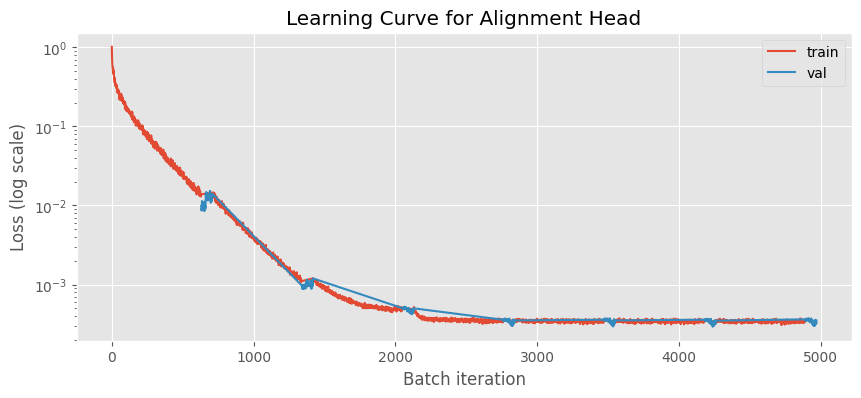

In [ ]:
plt.style.use("ggplot")

df = pd.read_csv("models/history1.csv")
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby("set").plot(y="loss", title="Loss", ax=ax)
plt.legend(["train", "val"])
plt.yscale("log")
plt.ylabel("Loss (log scale)")
plt.xlabel("Batch iteration")
plt.title("Learning Curve for Alignment Head")
plt.show()

As you can see above the loss, the MSE across the image and location embeddings is decreasing, which means that the alignment head is learning to align the image embeddings with the location embeddings. The loss hits a plateau after 4 epochs.

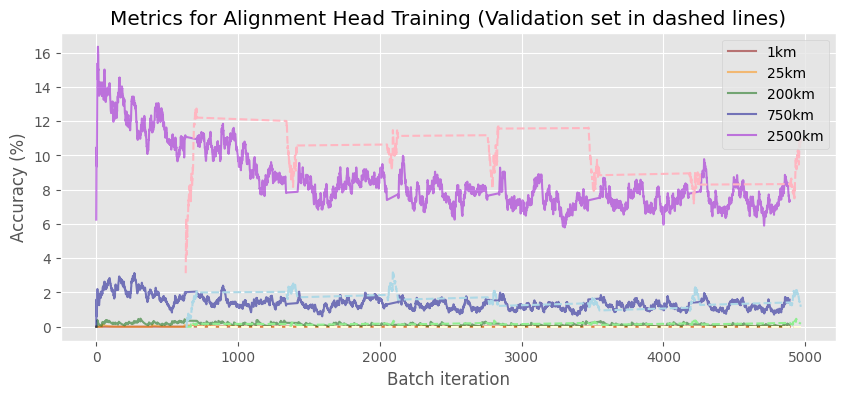

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
darkcolors = ["darkred", "darkorange", "darkgreen", "darkblue", "darkviolet"]
lightcolors = ["lightcoral", "lightyellow", "lightgreen", "lightblue", "lightpink"]
(100 * df.loc[df["set"] == "train", ["1", "25", "200", "750", "2500"]]).ewm(
    alpha=0.03
).mean().plot(ax=ax, color=darkcolors, alpha=0.5)
(100 * df.loc[df["set"] == "val", ["1", "25", "200", "750", "2500"]]).ewm(
    alpha=0.03
).mean().plot(ax=ax, color=lightcolors, linestyle="--")
plt.xlabel("Batch iteration")
plt.ylabel("Accuracy (%)")
plt.title("Metrics for Alignment Head Training (Validation set in dashed lines)")
plt.legend(["1km", "25km", "200km", "750km", "2500km"])
plt.show()

Although the loss is decreasing, the actual performance of the model is not improving. This is because we are using a different image encoder than the one used by Vincente et al. The test metrics below are inline with the training and validation metrics, which means that the model is not overfitting.

Table 1: Test metrics for the alignment head.
| Loss | Accuracy in 1km | Accuracy in 25km | Accuracy in 200km | Accuracy in 750km | Accuracy in 2500km |
|------|------------------|-------------------|--------------------|--------------------|---------------------|
| 0.000343 | 0.00% | 0.00% | 0.08% | 1.15% | 8.36% |

## Results for Training IA3

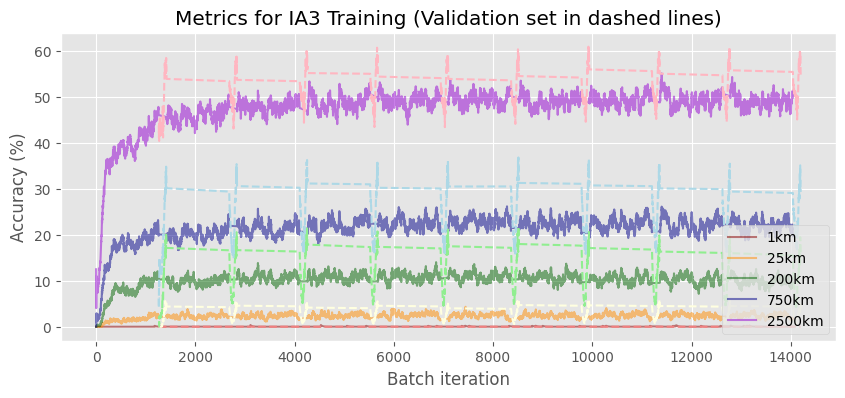

In [ ]:
df = pd.read_csv("models/history2.csv")
fig, ax = plt.subplots(figsize=(10, 4))
(100 * df.loc[df["set"] == "train", ["1", "25", "200", "750", "2500"]]).ewm(
    alpha=0.03
).mean().plot(ax=ax, color=darkcolors, alpha=0.5)
(100 * df.loc[df["set"] == "val", ["1", "25", "200", "750", "2500"]]).ewm(
    alpha=0.03
).mean().plot(ax=ax, color=lightcolors, linestyle="--")
plt.xlabel("Batch iteration")
plt.ylabel("Accuracy (%)")
plt.title("Metrics for IA3 Training (Validation set in dashed lines)")
plt.legend(["1km", "25km", "200km", "750km", "2500km"], loc="lower right")
plt.show()

After unfreezing the IA3 vectors and the location encoder, the model is able to learn the geographical features from the images and encode them in the latent space. You can see in the graph aove that the accuracy increased drastically after unfreezing the IA3 vectors and the location encoder. In fact, it is quite close to SoTA models, for streetview benchmarks.

One thing to note that the model reaches a plateau after 3-4 epochs, which one can think that it is quite fast but maybe too early. I haven't used any learning rate scheduler, so it is possible that the learning rate is too high and the model is not able to converge to a better solution.

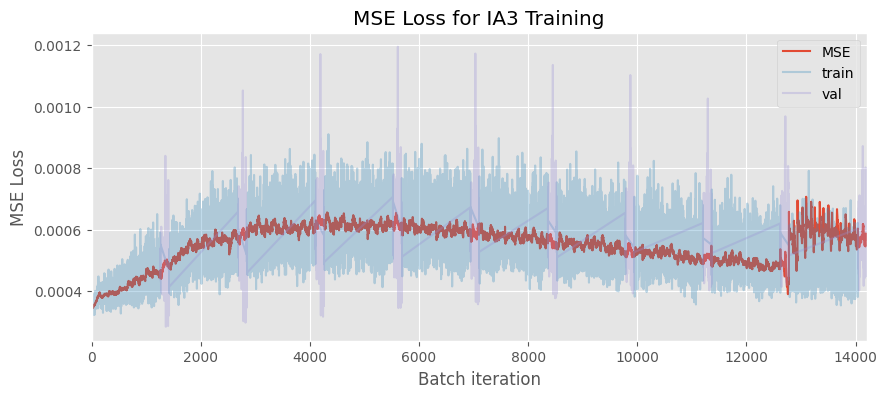

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(["set", "epoch"])[["mse"]].ewm(alpha=0.05).mean().reset_index().plot(
    y="mse", label="MSE", ax=ax
)
df[df["set"] == "train"].plot(y="mse", figsize=(10, 4), label="train", alpha=0.3, ax=ax)
df[df["set"] == "val"].plot(y="mse", figsize=(10, 4), label="val", alpha=0.3, ax=ax)
plt.xlim(0, len(df))
plt.legend()
plt.title("MSE Loss for IA3 Training")
plt.xlabel("Batch iteration")
plt.ylabel("MSE Loss")
plt.show()

One interesting finding was what happenned to the MSE between the image and location embeddings. As I have noted earliear, the first training session used MSE loss, and the second training session used Symmetric Cross Entropy loss (neccessary for contrastive learning). As you can see, switching the loss function initially increased the MSE, but then it slowly decreases. It looks like it was converging to a better solution, but it did not correlate with the accuracy.

Table 2: Test metrics for the IA3 model.
| Loss | Accuracy in 1km | Accuracy in 25km | Accuracy in 200km | Accuracy in 750km | Accuracy in 2500km |
|------|------------------|-------------------|--------------------|--------------------|---------------------|
| 0.000527 | 0.05% | 1.12% | 11.08% | 24.15% | 53.36% |

### Exercise 2: Interpreting the results (5 points)

**This exercise is required only for students that have not submitted the first homework, or for students who want to raise their mid-term mark (mark <= 8/10). For a mark of 8/10 or higher, an additional point can also be recovered during the exam.**

> **To recap**: if you submitted the mid-term homework, implement only Exercise 1, for a total of *10 points*. If you did not submit the mid-term homework, implement Exercises 1 and 2 for a total of *15 points*.

[LIME](https://arxiv.org/abs/1602.04938) (**Local Interpretable Model-agnostic Explanations**) is a very common explainability method, which trains a small interpretable model (e.g., a linear model) around a prediction $f(x)$ to interpret the prediction. For this exercise:

1. Read carefully the original LIME paper.
2. Re-implement the LIME algorithm and test it on 1 or 2 predictions given by your neural network (from Exercise 1).
3. This must be done fully in TensorFlow (same as the previous exercise).
4. LIME requires to select how to represent the inputs (e.g., patches of the original image). Explain your choice below.
5. Analyze the results you obtain.

In [ ]:
# TODO: Implement and test LIME.

### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.

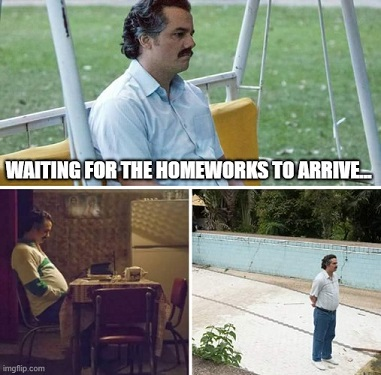